In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import sklearn as sk
from scipy import stats as st
from scipy.optimize import minimize
import pandas as pd
import os


In [2]:
np.set_printoptions(formatter={'float': lambda x: "{0:0.2e}".format(x)}) #to format printed numbers -> change 2 to the number of significant figures

## Functions ##

In [3]:
#for plotting distributions
def plot_distrib(data, bins = 100, title = ""):
    plt.hist(data, bins=bins, density=True)
    plt.title(title)
    plt.ylabel("Probability density")

In [4]:
#to calculate 1σ uncertainty bands and medians
def median_and_error(data):
    med, low, high = np.percentile(data, [50, 15.87, 84.13])
    median_and_error = np.array([med, low - med, high - med])

    return median_and_error

In [5]:
#Fits a skew-normal distribution to a given set of percentiles.
def fit_skewnorm(percentiles, values): #the percentiles and corresponding values

    #set initial guesses as if it was a gaussian
    median = np.interp(0.5, percentiles, values)
    p10 = np.interp(0.1, percentiles, values)
    p90 = np.interp(0.9, percentiles, values)
    init_scale = (p90 - p10) / 2.56 if (p90 - p10) > 0 else 1  #for a gaussian, p90-p10 ≈ 2.56 * σ


    initial_guesses = [0., median, init_scale]

    bounds = [(-20, 20), (None, None), (1e-6, None)] #(a, loc, scale) -> keep scale positive, and a bounded within a reasonable range

    #Error function to minimize
    def error_function(params):
        a, loc, scale = params
        theoretical_values = st.skewnorm.ppf(percentiles, a=a, loc=loc, scale=scale)
        return np.sum((theoretical_values - values) ** 2) #sum of squared errors

    result = minimize(
        error_function,
        initial_guesses,
        method='SLSQP',
        bounds=bounds,
        options={'ftol': 1e-9, 'disp': False}
    )

    return result.x #(a, loc, scale)

# Isolation Time Figure #

In [6]:
k = 2.3 #best

In [7]:
#production ratio
prIaNb = 1.58*10**-3
prIaSm =  0.347

EssNb = (3.2 * 10**-5, 0.3 * 10**-5)
EssSm = (8.28 * 10**-3, 0.44 * 10**-3)

#mean-life (half-life values from NUBASE)
tauNb = np.array([34.7, 2.4]) / np.log(2.)
tauSm = np.array([92, 2.6]) / np.log(2.)
tau = np.array([tauNb,tauSm])


#age of the galaxy
TGal = 8400

In [8]:
#τ for table
print(tau)

[[5.01e+01 3.46e+00]
 [1.33e+02 3.75e+00]]


## Fit skewnormal distribution to percentiles ##
Assuming assuming that a skew-normal distribution is a sufficient approximation for the assymetric distributions of the ISS ratios.

Percentiles from [Côté et al. (2019)](https://iopscience.iop.org/article/10.3847/1538-4357/ab5a88), $\gamma$ is taken to be 10 Myr.

In [9]:
percentiles = [0.16, 0.50, 0.84]

statNb = [3.13-0.73, 3.13, 3.13+0.80]
statSm = [9.99-0.84, 9.99, 9.99+0.87]

paramNb = fit_skewnorm(percentiles, statNb)
paramSm = fit_skewnorm(percentiles, statSm)

distNb = st.skewnorm(paramNb[0], paramNb[1], paramNb[2])
distSm = st.skewnorm(paramSm[0], paramSm[1], paramSm[2])

#normalise
paramNb[1:] = paramNb[1:] / distNb.mean()
paramSm[1:] = paramSm[1:] / distSm.mean()

#create normalised distribution
distNb = st.skewnorm(paramNb[0], paramNb[1], paramNb[2])
distSm = st.skewnorm(paramSm[0], paramSm[1], paramSm[2])

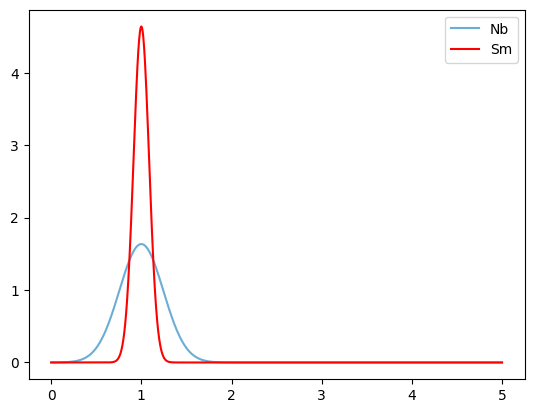

In [10]:
#visualising the fitted distributions
x = np.linspace(0,5,1000)
plt.plot(x,distNb.pdf(x=x),marker='none',label='Nb',color=plt.get_cmap('Blues')(2/4))
plt.plot(x,distSm.pdf(x=x),marker='none',label='Sm',color='r')
plt.legend()

## Calculate and plot isolation times for TypeIa prodcuction ##


Then I draw Monte Carlo distributions of the ESS and ISM ratios, and mean-lives. $\tau$ and ESS is assumed to be Gaussian, ISM
comes from the fitted skew-normal distributions.

In [11]:
mcNum = 10**7 #number of samples for MC

In [12]:
#Sampling distributions for the τ values
ratTauNb = np.clip(np.random.normal(loc = tauNb[0], scale = tauNb[1], size=mcNum), 1e-30, np.inf)
ratTauSm = np.clip(np.random.normal(loc = tauSm[0], scale = tauSm[1], size=mcNum), 1e-30, np.inf)

In [13]:
#The ISM ratios
IsmNb = k * prIaNb * ratTauNb / TGal
IsmSm = k * prIaSm * ratTauSm / TGal

In [14]:
#Sampling distributions for the ISM values
ratIsmNb = np.clip(IsmNb * distNb.rvs(mcNum), 1e-30, np.inf)
ratIsmSm = np.clip(IsmSm * distSm.rvs(mcNum), 1e-30, np.inf)

In [15]:
#Sampling normal distribution for the ESS values
ratEssNb = np.clip(np.random.normal(loc = EssNb[0], scale = EssNb[1], size=mcNum), 1e-30, np.inf)
ratEssSm = np.clip(np.random.normal(loc = EssSm[0], scale = EssSm[1], size=mcNum), 1e-30, np.inf)

In [16]:
#Calculating isolation time
isoTNb = -np.log(ratEssNb / ratIsmNb) * ratTauNb
isoTSm = -np.log(ratEssSm / ratIsmSm) * ratTauSm

In [17]:
#downsample for visualisation (this is for optimisation)
isoTSampleNb = sk.utils.resample(isoTNb, n_samples=1000000)
isoTSampleSm = sk.utils.resample(isoTSm, n_samples=1000000)

In [18]:
#create the approximate isolation time distributions
isoTSampleNbKern = sk.neighbors.KernelDensity(kernel='gaussian', bandwidth=1, algorithm='auto')
isoTSampleNbKern.fit(isoTSampleNb.reshape(-1, 1))
isoTSampleSmKern = sk.neighbors.KernelDensity(kernel='gaussian', bandwidth=1, algorithm='auto')
isoTSampleSmKern.fit(isoTSampleSm.reshape(-1, 1))

,bandwidth,1
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [19]:
x = np.linspace(-120, 120, 100).reshape(-1, 1)

In [20]:
#evaluate the distribution at 100 points
isoTSampleNbDensity = np.exp(isoTSampleNbKern.score_samples(x))
isoTSampleSmDensity = np.exp(isoTSampleSmKern.score_samples(x))

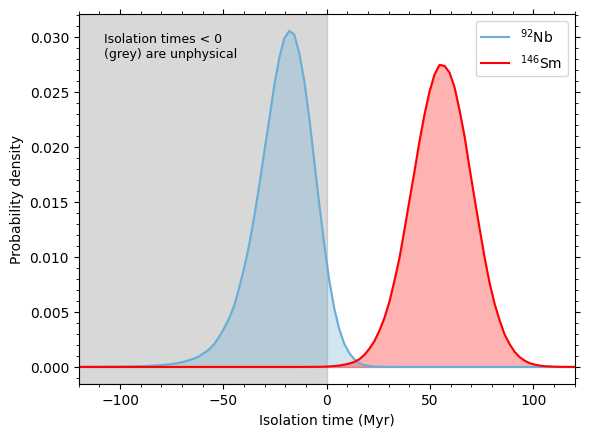

In [21]:
#Creating figure
blue = plt.get_cmap('Blues')(2/4)

plt.plot(x, isoTSampleNbDensity, color=blue, label='$^{92}$Nb')
plt.fill_between(x.flatten(), isoTSampleNbDensity, 0, color=blue,  alpha=0.3)

plt.plot(x, isoTSampleSmDensity, color='red', label='$^{146}$Sm')
plt.fill_between(x.flatten(), isoTSampleSmDensity, 0, color='red',  alpha=0.3)

plt.xlabel('Isolation time (Myr)')
plt.ylabel('Probability density')
plt.legend(loc='upper right')

#for tickmarks
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().tick_params(axis='x', which='both', top=True)
plt.gca().tick_params(axis='y', which='both', right=True)

plt.legend(loc='upper right')

#for the gray box
plt.axvspan(xmin=x.flatten()[0], xmax=0, color='gray', alpha=0.3, zorder=0)
plt.text(0.05, 0.95, "Isolation times < 0 \n(grey) are unphysical", transform=plt.gca().transAxes, fontsize=9, color='black', ha='left', va='top')

plt.xlim(x[0], x[-1])

plt.savefig("../figures/"+"isoT_Ia.png",bbox_inches='tight')
plt.show()

## Calculate and plot isolation times for CCSN prodcuction ##


In [22]:
# Import production ratios of different CCSN models
data = pd.read_csv("../data/production_ratios.txt", sep='\\s+')
data = data.set_index("model")

In [23]:
shock = np.array(data['initial_shock'])
mtot = np.array(data['MTOT'])
mrem = np.array(data['MREM'])
msurf = np.array(data['MSURF'])
modelSet = np.array(data['Set'])

prCCSnNb = np.array(data['Nb-92/Mo-92'])
prCCSnSm =  np.array(data['Sm-146/Sm-144'])

In [24]:
mcNum = 10**7 #number of samples for MC

In [25]:
#Sampling distributions for the τ values
ratTauNb = np.clip(np.random.normal(loc=tauNb[0], scale=tauNb[1], size=mcNum), 1e-30, np.inf)
ratTauSm = np.clip(np.random.normal(loc=tauSm[0], scale=tauSm[1], size=mcNum), 1e-30, np.inf)

In [26]:
#The ISM ratios
IsmNbCCSn = k * prCCSnNb[:, np.newaxis] * ratTauNb / TGal
IsmSmCCSn = k * prCCSnSm[:, np.newaxis] * ratTauSm / TGal

In [27]:
ratIsmNbCCSn = np.clip(IsmNbCCSn * distNb.rvs(mcNum), 1e-30, np.inf)
ratIsmSmCCSn = np.clip(IsmSmCCSn * distSm.rvs(mcNum), 1e-30, np.inf)

isoTNbCCSn = -np.log(ratEssNb/ ratIsmNbCCSn) * ratTauNb
isoTSmCCSn = -np.log(ratEssSm / ratIsmSmCCSn) * ratTauSm

In [28]:
isoTSampleNbCCSn = []
isoTSampleSmCCSn = []

for i in range(np.size(prCCSnNb)):
    isoTSampleNbCCSn.append(sk.utils.resample(isoTNbCCSn[i], n_samples=1000000))
    isoTSampleSmCCSn.append(sk.utils.resample(isoTSmCCSn[i], n_samples=1000000))

In [29]:
isoTNbKernCCSn = []
isoTSmKernCCSn = []

for i in range(np.size(prCCSnNb)):
    isoTNbKernCCSn.append(sk.neighbors.KernelDensity(kernel='gaussian', bandwidth=1, algorithm='auto'))
    isoTNbKernCCSn[i].fit(isoTSampleNbCCSn[i].reshape(-1, 1))
    isoTSmKernCCSn.append(sk.neighbors.KernelDensity(kernel='gaussian', bandwidth=1, algorithm='auto'))
    isoTSmKernCCSn[i].fit(isoTSampleSmCCSn[i].reshape(-1, 1))

In [30]:
#create the ranges for plotting the data (limits selected based on previous run)
limits = np.array([[-150,50],[-150,50],[-150,110],[-150,110],[-380,110]])
x = np.linspace(limits[:,0], limits[:,1], 100).T

In [31]:
#evaluate the distributions at 100 points
isoTNbDensityBest_CCSn = []
isoTSmDensityBest_CCSn = []

for i in range(np.size(prCCSnNb)):
    isoTNbDensityBest_CCSn.append(np.exp(isoTNbKernCCSn[i].score_samples(x[i].reshape(-1, 1))))
    isoTSmDensityBest_CCSn.append(np.exp(isoTSmKernCCSn[i].score_samples(x[i].reshape(-1, 1))))

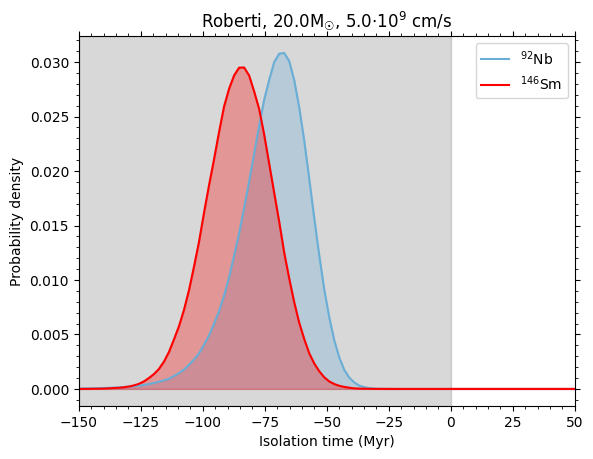

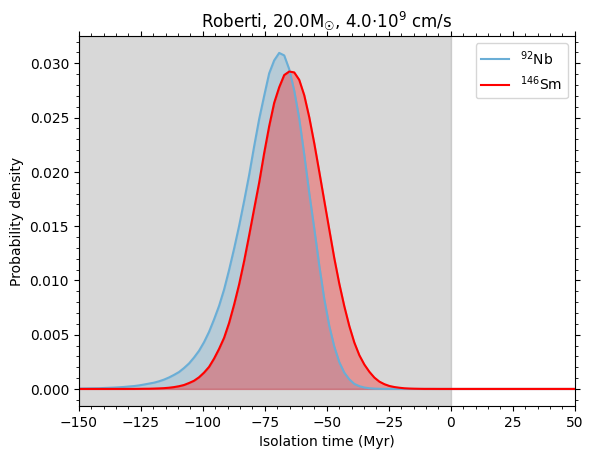

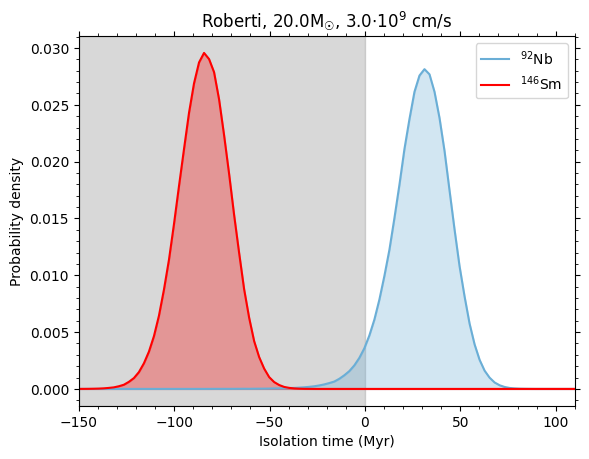

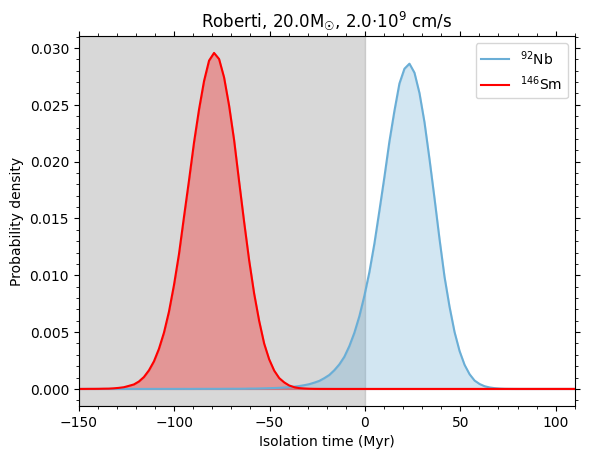

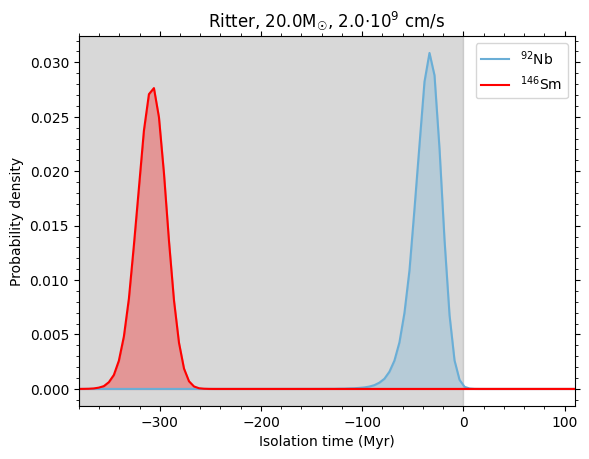

In [32]:
blue = plt.get_cmap('Blues')(2/4)

for i in range(np.size(prCCSnNb)):

    plt.plot(x[i], isoTNbDensityBest_CCSn[i], color=blue, label='$^{92}$Nb')
    plt.fill_between(x[i], isoTNbDensityBest_CCSn[i], 0, color=blue,  alpha=0.3)

    #for tickmarks
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
    plt.gca().tick_params(axis='x', which='both', top=True)
    plt.gca().tick_params(axis='y', which='both', right=True)

    plt.plot(x[i], isoTSmDensityBest_CCSn[i], color="red", label='$^{146}$Sm')
    plt.fill_between(x[i].flatten(), isoTSmDensityBest_CCSn[i], 0, color="red",  alpha=0.3)

    plt.xlabel('Isolation time (Myr)')
    plt.ylabel('Probability density')
    plt.legend(loc='upper right')

    #for the gray box
    plt.axvspan(xmin=x[i][0], xmax=0, color='gray', alpha=0.3, zorder=0)
    #plt.text(0.05, 0.95, "Isolation times < 0 \n(grey) are unphysical", transform=plt.gca().transAxes, fontsize=9, color='black', ha='left', va='top')

    plt.xlim(x[i][0], x[i][-1])

    plt.title(modelSet[i]+", "+str(mtot[i])+"M$_☉$, "+str(shock[i])+"$\\cdot10^9$ cm/s")

    plt.savefig("../figures/"+modelSet[i]+"_M"+str(int(mtot[i]))+"_V"+str(shock[i]).replace('.', 'p'))
    plt.show()

## 1$\sigma$ uncertainty bands for ISS ratios ##


In [33]:
#median, -, +
for i in range(np.size(prCCSnNb)):
    print(modelSet[i]+", "+str(mtot[i])+"M☉, "+str(shock[i])+" ⋅ 10⁹ cm/s")
    print("Nb: ",median_and_error(ratIsmNbCCSn[i]))
    print("Sm: ",median_and_error(ratIsmSmCCSn[i]))
    print()

Roberti, 20.0M☉, 5.0 ⋅ 10⁹ cm/s
Nb:  [7.75e-06 -1.94e-06 2.01e-06]
Sm:  [4.36e-03 -3.92e-04 3.98e-04]

Roberti, 20.0M☉, 4.0 ⋅ 10⁹ cm/s
Nb:  [7.66e-06 -1.91e-06 1.98e-06]
Sm:  [5.07e-03 -4.55e-04 4.62e-04]

Roberti, 20.0M☉, 3.0 ⋅ 10⁹ cm/s
Nb:  [5.87e-05 -1.47e-05 1.52e-05]
Sm:  [4.39e-03 -3.94e-04 4.00e-04]

Roberti, 20.0M☉, 2.0 ⋅ 10⁹ cm/s
Nb:  [4.95e-05 -1.24e-05 1.28e-05]
Sm:  [4.55e-03 -4.09e-04 4.15e-04]

Ritter, 20.0M☉, 2.0 ⋅ 10⁹ cm/s
Nb:  [1.58e-05 -3.94e-06 4.08e-06]
Sm:  [8.11e-04 -7.28e-05 7.40e-05]



## 1$\sigma$ uncertainty bands for the Isolation Times ##


In [34]:
#median, -, +
for i in range(np.size(prCCSnNb)):
    print(modelSet[i]+", "+str(mtot[i])+"M☉, "+str(shock[i])+" ⋅ 10⁹ cm/s")
    print("Nb: ",median_and_error(isoTNbCCSn[i]))
    print("Sm: ",median_and_error(isoTSmCCSn[i]))
    print()

Roberti, 20.0M☉, 5.0 ⋅ 10⁹ cm/s
Nb:  [-7.05e+01 -1.48e+01 1.20e+01]
Sm:  [-8.49e+01 -1.38e+01 1.33e+01]

Roberti, 20.0M☉, 4.0 ⋅ 10⁹ cm/s
Nb:  [-7.12e+01 -1.48e+01 1.20e+01]
Sm:  [-6.51e+01 -1.38e+01 1.33e+01]

Roberti, 20.0M☉, 3.0 ⋅ 10⁹ cm/s
Nb:  [3.02e+01 -1.52e+01 1.37e+01]
Sm:  [-8.42e+01 -1.38e+01 1.33e+01]

Roberti, 20.0M☉, 2.0 ⋅ 10⁹ cm/s
Nb:  [2.17e+01 -1.51e+01 1.34e+01]
Sm:  [-7.94e+01 -1.38e+01 1.33e+01]

Ritter, 20.0M☉, 2.0 ⋅ 10⁹ cm/s
Nb:  [-3.52e+01 -1.46e+01 1.21e+01]
Sm:  [-3.08e+02 -1.47e+01 1.40e+01]



### References: ###
- Leckenby, G., Sidhu, R. S., Chen, R. J., Szányi, B., Dillmann, I., Gernhäuser, R., Glorius, J., Griffin, C., Litvinov, Y. A., Lugaro, M., Sanjari, S., & Yagüe Lopéz, A. (2024).
Measurement of the bound-state beta decay of 205Tl(81+): analysis scripts and figures (1.0).
Zenodo. https://doi.org/10.5281/zenodo.11560338
- Côté, Benoit et al. (Dec. 2019). “Stochastic Chemical Evolution of Radioactive Isotopes
with a Monte Carlo Approach”. In: ApJ 887.2, 213, p. 213. doi: [10.3847/1538-
4357/ab5a88](https://iopscience.iop.org/article/10.3847/1538-4357/ab5a88). arXiv: [1911.01457 [astro-ph.GA]](https://arxiv.org/abs/1911.01457).